### **STUDENT INFORMATION**
Name: **Linet K. Mutuma**

Student pace: **Part Time**

Instructor: **Bonface Manyara**

### **BUSINESS UNDERSTANDING**
To analyzes maize and sorghum production in the Karamoja region of Uganda at both district and subcounty levels. The analysis explores production patterns, population influence, land use efficiency and yield distribution to support data-driven decision making for agricultural planning and resource allocation

### **BUSINESS QUESTIONS**

1. Which sub-counties have the highest crop yields?

2. Which district produces the most total food?

3. Where should we deploy resources first?

4. Which crops are performing better in which areas?

5. Which areas show potential for rapid improvement?

### **IMPORT LIBRARIES**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shapefile

#### **UNZIP FILES**
For ease in accessing dataset

In [3]:
def read_shp(file_path):
    sf = shapefile.Reader(file_path)
    fields = [f[0] for f in sf.fields[1:]]
    records = sf.records()
    df = pd.DataFrame(records, columns=fields)
    return df

# district_shp = read_shp("DATA/SHAPEFILES/Uganda_Districts.shp")
# subcounty_shp = read_shp("DATA/SHAPEFILES/Uganda_Subcounties.shp")
# maize_shp = read_shp("DATA/SHAPEFILES/Crop_Type_Map_Maize.shp")
# sorghum_shp = read_shp("DATA/SHAPEFILES/Crop_Type_Map_Sorghum.shp")

district_shp = read_shp("https://raw.githubusercontent.com/linetmutuma1-a11y/project-karamoja-/main/DATA/SHAPEFILES/Uganda_Districts.shp")
subcounty_shp = read_shp("https://raw.githubusercontent.com/linetmutuma1-a11y/project-karamoja-/main/DATA/SHAPEFILES/Uganda_Subcounties.shp")
maize_shp = read_shp("https://raw.githubusercontent.com/linetmutuma1-a11y/project-karamoja-/main/DATA/SHAPEFILES/Crop_Type_Map_Maize.shp")
sorghum_shp = read_shp("https://raw.githubusercontent.com/linetmutuma1-a11y/project-karamoja-/main/DATA/SHAPEFILES/Crop_Type_Map_Sorghum.shp")



#### **LOADING DATASET**
This is the most important part during analysis. Without loading data, we wont be able to read and come up with insights so this step will be done  through the following code:

In [4]:
# district_df=pd.read_csv('Uganda_Karamoja_District_Crop_Yield_Population.csv')
# subcounty_df=pd.read_csv('Uganda_Karamoja_Subcounty_Crop_Yield_Population.csv')

subcounty_df=pd.read_csv('https://raw.githubusercontent.com/linetmutuma1-a11y/project-karamoja-/main/Uganda_Karamoja_Subcounty_Crop_Yield_Population.csv')
district_df=pd.read_csv('https://raw.githubusercontent.com/linetmutuma1-a11y/project-karamoja-/main/Uganda_Karamoja_District_Crop_Yield_Population.csv')

### **EXPLORE THE DATA**

In [5]:
# summary information about the dataset
district_df.info()
subcounty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OBJECTID      7 non-null      int64  
 1   NAME          7 non-null      object 
 2   POP           7 non-null      int64  
 3   Area          7 non-null      int64  
 4   S_Yield_Ha    7 non-null      int64  
 5   M_Yield_Ha    7 non-null      int64  
 6   Crop_Area_Ha  7 non-null      float64
 7   S_Area_Ha     7 non-null      float64
 8   M_Area_Ha     7 non-null      float64
 9   S_Prod_Tot    7 non-null      int64  
 10  M_Prod_Tot    7 non-null      int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 748.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OBJECTID        52 non-null     int64  
 1   SUBCOUNTY_NAME  52 non-null   

In [6]:
district_df.head()

,OBJECTID,NAME,POP,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,92,ABIM,90385,2771977106,449,1040,5470.068394,3277.295971,1848.621855,1471506,1922567
1,96,AMUDAT,101790,1643582836,205,1297,5765.443719,2973.423860,2733.661014,609552,3545558
2,20,KAABONG,627057,7373606003,279,945,28121.672530,20544.194960,7394.416334,5731830,6987723
3,85,KOTIDO,243157,3641539808,331,1148,53032.649450,50247.443900,1751.372284,16631904,2010575
4,5,MOROTO,127811,3570160948,128,355,5954.814048,4741.748776,1190.050606,606944,422468


In [7]:
subcounty_df.head()

,OBJECTID,SUBCOUNTY_NAME,DISTRICT_NAME,POP,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,263,KACHERI,KOTIDO,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900
1,264,KOTIDO,KOTIDO,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500
2,265,KOTIDO TOWN COUNCIL,KOTIDO,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268
3,266,NAKAPERIMORU,KOTIDO,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080
4,267,PANYANGARA,KOTIDO,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400


In [8]:
# shape to see the number of rows and columns in the dataset
print(f'shape of the district dataset:{district_df.shape}\nshape of the subcounty dataset:{subcounty_df.shape}')

shape of the district dataset:(7, 11)
shape of the subcounty dataset:(52, 13)


In [9]:
# count the unique values in the district and subcounty names columns
district_df.NAME.value_counts()



,count
NAME,
ABIM,1
AMUDAT,1
KAABONG,1
KOTIDO,1
MOROTO,1
NAKAPIRIPIRIT,1
NAPAK,1


In [10]:
subcounty_df.DISTRICT_NAME.value_counts()
#This shows how many subcountries are in each district.

,count
DISTRICT_NAME,
KAABONG,14
NAKAPIRIPIRIT,8
NAPAK,8
ABIM,6
KOTIDO,6
MOROTO,6
AMUDAT,4


### **CHECKING OF NUN VALUES**

In [11]:
district_df.isnull().sum()* 100/len(district_df)
# there are no missing values in the district dataset

,0
OBJECTID,0.0
NAME,0.0
POP,0.0
Area,0.0
S_Yield_Ha,0.0
M_Yield_Ha,0.0
Crop_Area_Ha,0.0
S_Area_Ha,0.0
M_Area_Ha,0.0
S_Prod_Tot,0.0


In [12]:
subcounty_df.isnull().sum()*100/len(subcounty_df)
# there are no missing values in the subcounty dataset

,0
OBJECTID,0.0
SUBCOUNTY_NAME,0.0
DISTRICT_NAME,0.0
POP,0.0
Area,0.0
Karamoja,0.0
S_Yield_Ha,0.0
M_Yield_Ha,0.0
Crop_Area_Ha,0.0
S_Area_Ha,0.0


#### **MAKING A COPY OF THE DATASET FOR MANIPULATION**

In [13]:
dist_df=district_df.copy()
sub_cty_df=subcounty_df.copy()

##### Refining the column names for both dataset

In [14]:
# columns names specification to make them more easy to understand and work with
new_cols_dict = {
    'OBJECTID': 'Object_id',
    'NAME': 'District',
    'POP':'Population'

}
dist_df.rename(columns=new_cols_dict, inplace=True)



In [15]:
dist_df.head()



,Object_id,District,Population,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,92,ABIM,90385,2771977106,449,1040,5470.068394,3277.295971,1848.621855,1471506,1922567
1,96,AMUDAT,101790,1643582836,205,1297,5765.443719,2973.423860,2733.661014,609552,3545558
2,20,KAABONG,627057,7373606003,279,945,28121.672530,20544.194960,7394.416334,5731830,6987723
3,85,KOTIDO,243157,3641539808,331,1148,53032.649450,50247.443900,1751.372284,16631904,2010575
4,5,MOROTO,127811,3570160948,128,355,5954.814048,4741.748776,1190.050606,606944,422468


In [16]:
# columns names specification for easy work flow and understanding
new_cols_dict = {
        'OBJECTID': 'Object_id',
    'DISTRICT_NAME': 'District',
    'SUBCOUNTY_NAME': 'Subcounty',
    'POP':'Population'

}
sub_cty_df.rename(columns=new_cols_dict, inplace=True)

In [17]:
sub_cty_df.head()

,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,263,KACHERI,KOTIDO,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900
1,264,KOTIDO,KOTIDO,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500
2,265,KOTIDO TOWN COUNCIL,KOTIDO,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268
3,266,NAKAPERIMORU,KOTIDO,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080
4,267,PANYANGARA,KOTIDO,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400


##### Title Case

In [18]:
# change the title case of the columns names to make them more consistent
dist_df.District = dist_df.District.str.title()
dist_df

,Object_id,District,Population,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,92,Abim,90385,2771977106,449,1040,5470.068394,3277.295971,1848.621855,1471506,1922567
1,96,Amudat,101790,1643582836,205,1297,5765.443719,2973.423860,2733.661014,609552,3545558
2,20,Kaabong,627057,7373606003,279,945,28121.672530,20544.194960,7394.416334,5731830,6987723
3,85,Kotido,243157,3641539808,331,1148,53032.649450,50247.443900,1751.372284,16631904,2010575
4,5,Moroto,127811,3570160948,128,355,5954.814048,4741.748776,1190.050606,606944,422468
5,54,Nakapiripirit,146780,4216323900,356,1264,26372.698490,19237.333210,6425.788414,6848491,8122197
6,80,Napak,167625,4508782023,137,854,22944.296020,16142.015880,6543.719066,2211456,5588336


In [19]:
sub_cty_df.Subcounty,sub_cty_df.District = sub_cty_df.Subcounty.str.title(), sub_cty_df.District.str.title()
sub_cty_df.head()

,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400


#### **JOINING TABLES FOR A MORE ENRICHED DATASET**

In [20]:
# merging the two datasets on the common column 'District' to create a new dataframe called karamoja_df
karamoja_df= pd.merge(sub_cty_df,dist_df,on='District',suffixes=('_S','_D'))
karamoja_df
# helps unhide columns in the dataframe
pd.set_option('display.max_columns', None)
karamoja_df.head()

,Object_id_S,Subcounty,District,Population_S,Area_S,Karamoja,S_Yield_Ha_S,M_Yield_Ha_S,Crop_Area_Ha_S,S_Area_Ha_S,M_Area_Ha_S,S_Prod_Tot_S,M_Prod_Tot_S,Object_id_D,Population_D,Area_D,S_Yield_Ha_D,M_Yield_Ha_D,Crop_Area_Ha_D,S_Area_Ha_D,M_Area_Ha_D,S_Prod_Tot_D,M_Prod_Tot_D
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575


In [21]:
#Here checking the columns of the new dataframe
karamoja_df.columns

Index(['Object_id_S', 'Subcounty', 'District', 'Population_S', 'Area_S',
       'Karamoja', 'S_Yield_Ha_S', 'M_Yield_Ha_S', 'Crop_Area_Ha_S',
       'S_Area_Ha_S', 'M_Area_Ha_S', 'S_Prod_Tot_S', 'M_Prod_Tot_S',
       'Object_id_D', 'Population_D', 'Area_D', 'S_Yield_Ha_D', 'M_Yield_Ha_D',
       'Crop_Area_Ha_D', 'S_Area_Ha_D', 'M_Area_Ha_D', 'S_Prod_Tot_D',
       'M_Prod_Tot_D'],
      dtype='object')

#### **FILTERING DOWN**

In [22]:
#filtering the columns to only include the relevant columns for analysis of the relationship between sorghum and maize prodction at the disstrict level
karamoja_df= pd.merge(sub_cty_df,dist_df[["District","S_Prod_Tot","M_Prod_Tot"]],on='District',suffixes=('_S','_D'))
karamoja_df.head()



,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot_S,M_Prod_Tot_S,S_Prod_Tot_D,M_Prod_Tot_D
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900,16631904,2010575
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500,16631904,2010575
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268,16631904,2010575
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080,16631904,2010575
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400,16631904,2010575


#### **FEATURE ENGINEERING**

Let's caluculate:

1. Productivity per Person (Kg/person) = Total Production ÷ Population

1. POP_DENSITY( that is populaion density)

4. Land Efficiency

**Production per Capita**

In [23]:
# Calculate agricultural output per person (kg/person).
karamoja_df['Prod_Per_Capita'] = karamoja_df['M_Prod_Tot_D'] / karamoja_df['Population']

**Population Density**

In [24]:
 # Calculate people per unit area.
karamoja_df['Pop_Density'] = karamoja_df['Area'] / karamoja_df['Population']

**Land Use Efficiency**

In [25]:
#Create subcounty land-yield ratio to investigate land use efficiency
# Calculate percentage of land used for crops.
karamoja_df['Land_Use_Efficiency'] = (karamoja_df['Crop_Area_Ha'] / karamoja_df['Area']) * 100
karamoja_df.head()

,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot_S,M_Prod_Tot_S,S_Prod_Tot_D,M_Prod_Tot_D,Prod_Per_Capita,Pop_Density,Land_Use_Efficiency
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900,16631904,2010575,116.595627,61886.810195,0.000658
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500,16631904,2010575,38.099998,11323.931478,0.002274
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268,16631904,2010575,73.408120,875.256526,0.006910
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080,16631904,2010575,51.852353,10808.809568,0.001691
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400,16631904,2010575,30.600496,13407.949744,0.001180


#### **ANALYSIS**

This is visualizing the relationship between maize and sorghum production at the district level using a stacked bar chart

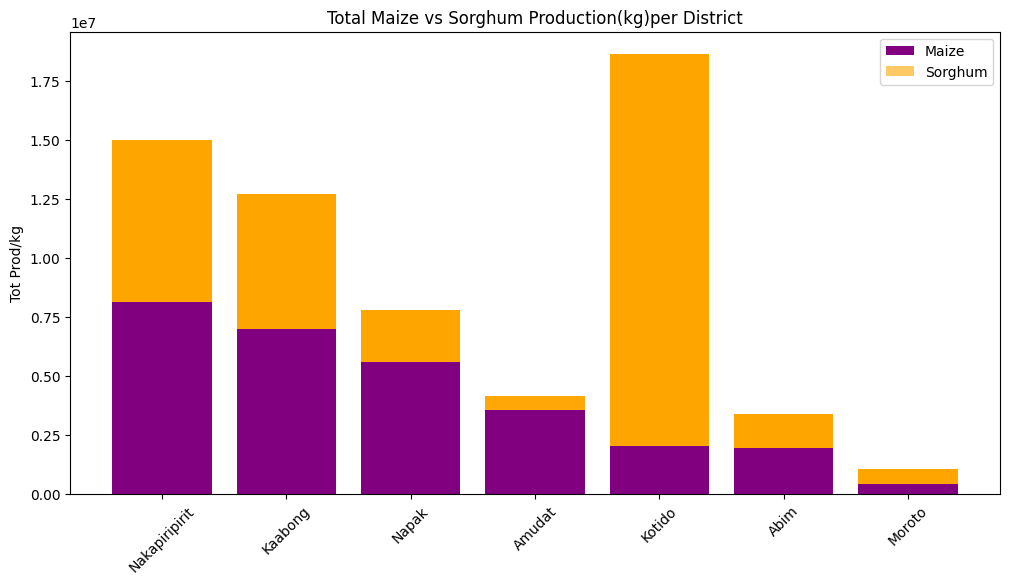

In [26]:
# sorting and assigning the sorted dataframe a new variable for better visualization

karamoja_df_sorted = karamoja_df.sort_values(
    by=["M_Prod_Tot_D", "S_Prod_Tot_D"],
    ascending=[False, False]
)

plt.figure(figsize=(12,6))
plt.bar(karamoja_df_sorted['District'], karamoja_df_sorted["M_Prod_Tot_D"], label="Maize",  color="Purple")
plt.bar(karamoja_df_sorted["District"], karamoja_df_sorted["S_Prod_Tot_D"], bottom=karamoja_df_sorted["M_Prod_Tot_D"],
        label="Sorghum", alpha=0.6, color="Orange")
plt.xticks(rotation=45)
plt.ylabel("Tot Prod/kg")
plt.title("Total Maize vs Sorghum Production(kg)per District")
plt.legend()
plt.show()

##### **Observation**
Maize production exceeds sorghum across all districts; Kotido shows highest sorghum production; Moroto has lowest overall production.


#### **HISTOGRAM**

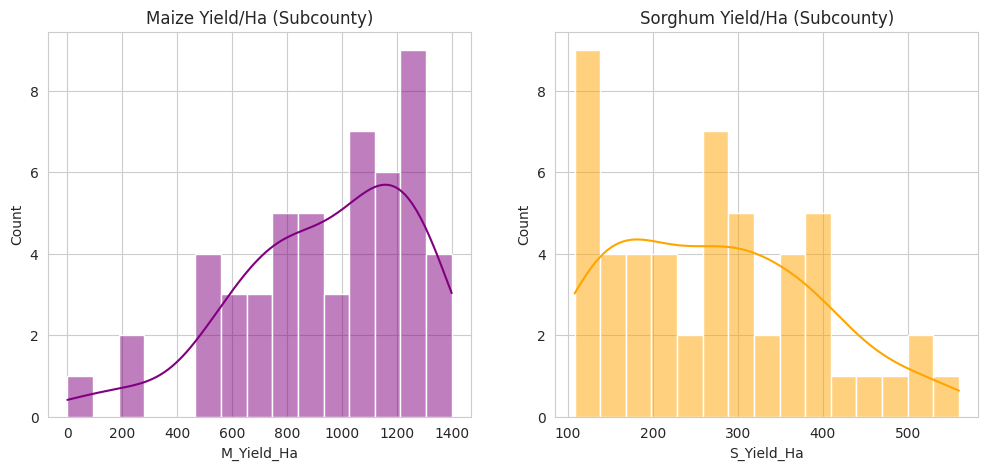

In [27]:
# visualizing using histograms to see the distribution of yeild at a subcounty level for both maize and sorghum

sns.set_style("whitegrid")
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.histplot(karamoja_df["M_Yield_Ha"], bins=15, kde=True, ax=axes[0], color="Purple")
axes[0].set_title("Maize Yield/Ha (Subcounty)")

sns.histplot(karamoja_df["S_Yield_Ha"], bins=15, kde=True, ax=axes[1], color="Orange")
axes[1].set_title("Sorghum Yield/Ha (Subcounty)")
plt.show()

#### **CORRELATION**

##### **Observation**
Maize shows slight negative skew (most subcounties have relatively high yields); Sorghum shows slight positive skew (some very high productivity  areas).  

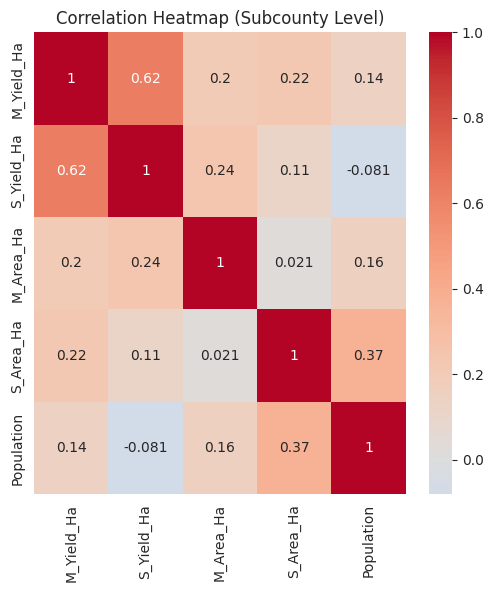

In [28]:
# creating a correlation heatmap to see the relationship between the different variables in the dataset

plt.figure(figsize=(6,6))
sns.heatmap(karamoja_df[["M_Yield_Ha", "S_Yield_Ha", "M_Area_Ha", "S_Area_Ha", "Population"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Subcounty Level)")
plt.show()

##### **Observation**

Strong positive correlation between maize and sorghum yields

Weak correlation between cultivation area and yield

Yield depends more on productivity factors than area size



#### **EXPORTING**

In [29]:
# saving the cleaned and merged dataframe to a new csv file for future use and analysis
karamoja_df.to_csv('karamoja_df.csv', index=False)